In [2]:
#import core libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load data
df=pd.read_csv(r"c:\Users\dell\Downloads\Sales Dataset.csv")
df

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,6/27/2023,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,12/27/2024,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,7/25/2021,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,6/27/2023,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,12/27/2024,Connor Morgan,Illinois,Chicago,2024-12
...,...,...,...,...,...,...,...,...,...,...,...,...
1189,B-26370,8825,3594,15,Furniture,Tables,Debit Card,7/31/2024,Megan Mclean,New York,New York City,2024-07
1190,B-26298,2082,642,8,Electronics,Phones,EMI,6/2/2020,Caitlin Hunt,New York,Rochester,2020-06
1191,B-26298,2082,642,8,Electronics,Phones,EMI,12/15/2022,Jenna Holland,Texas,Austin,2022-12
1192,B-26298,2082,642,8,Electronics,Phones,EMI,8/7/2020,Stephanie Oconnell,New York,Buffalo,2020-08


In [ ]:
#Missing values check
df.isnull().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64

In [4]:
df.isna().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64

In [ ]:
#Duplicate rows check
df.duplicated().sum()

np.int64(0)

In [ ]:
#Negative profit check
print((df['Profit'] < 0).sum())
df[df['Profit'] < 0].head()

0


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month,year,month,Month


In [6]:
df.head(10)

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
5,B-26776,4975,1330,14,Electronics,Printers,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
6,B-26942,1525,185,12,Office Supplies,Pens,Debit Card,2024-05-11,John Fields,Florida,Orlando,2024-05
7,B-26942,1525,185,12,Office Supplies,Pens,Debit Card,2021-10-09,Clayton Smith,Florida,Miami,2021-10
8,B-26640,883,117,10,Electronics,Laptops,EMI,2022-11-18,Richard Kelley,California,Los Angeles,2022-11
9,B-26640,8127,3551,16,Furniture,Tables,Credit Card,2022-11-18,Richard Kelley,California,Los Angeles,2022-11


In [ ]:
#Schema check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order ID      1194 non-null   str  
 1   Amount        1194 non-null   int64
 2   Profit        1194 non-null   int64
 3   Quantity      1194 non-null   int64
 4   Category      1194 non-null   str  
 5   Sub-Category  1194 non-null   str  
 6   PaymentMode   1194 non-null   str  
 7   Order Date    1194 non-null   str  
 8   CustomerName  1194 non-null   str  
 9   State         1194 non-null   str  
 10  City          1194 non-null   str  
 11  Year-Month    1194 non-null   str  
dtypes: int64(3), str(9)
memory usage: 112.1 KB


In [ ]:
#Summary statistics
df.describe()

,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [ ]:

#Order structure check
df.groupby('Order ID').agg({
    'CustomerName': 'nunique',
    'Order Date': 'nunique',
    'Sub-Category': 'nunique'
}).head(10)

,CustomerName,Order Date,Sub-Category
Order ID,,,
B-25004,2,2,1
B-25006,3,3,1
B-25010,2,2,1
B-25011,2,2,1
B-25022,2,2,1
B-25024,2,2,1
B-25025,1,1,2
B-25028,1,1,1
B-25030,1,1,1


In [ ]:
#Cardinality check
df.nunique()

Order ID        547
Amount          773
Profit          707
Quantity         20
Category          3
Sub-Category     12
PaymentMode       5
Order Date      648
CustomerName    802
State             6
City             18
Year-Month       61
dtype: int64

In [ ]:
#Column list
print(df.columns.tolist())

['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category', 'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City', 'Year-Month']


In [ ]:
#Categorical distribution
cat_cols=['Category','Sub-Category','PaymentMode','CustomerName','State']

for col in cat_cols:
    print(df[col].value_counts())
    print('\n')

Category
Furniture          407
Office Supplies    399
Electronics        388
Name: count, dtype: int64


Sub-Category
Tables              122
Pens                114
Sofas               114
Markers             110
Electronic Games    104
Paper               104
Phones              101
Printers             95
Laptops              88
Bookcases            88
Chairs               83
Binders              71
Name: count, dtype: int64


PaymentMode
Debit Card     260
Credit Card    258
UPI            252
EMI            218
COD            206
Name: count, dtype: int64


CustomerName
Jacqueline Harris     4
Kelsey Castaneda      4
Katherine Harris      4
Andrew Allen          4
Renee Solomon         4
                     ..
Megan Mclean          1
Caitlin Hunt          1
Jenna Holland         1
Stephanie Oconnell    1
Andrea Hill           1
Name: count, Length: 802, dtype: int64


State
New York      226
California    218
Florida       200
Texas         189
Illinois      181
Ohio          18

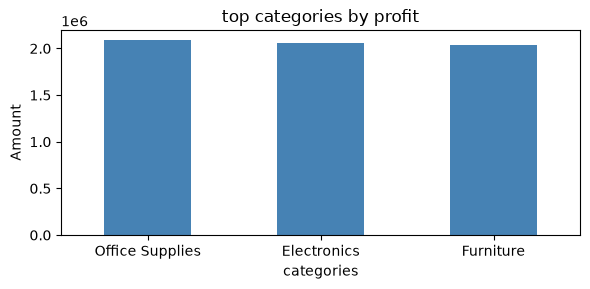

In [8]:
#Profit by category
top_categories=df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
top_categories.plot(kind='bar',figsize=(6,3),color='steelblue')
plt.title('top categories by profit')
plt.xlabel('categories')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

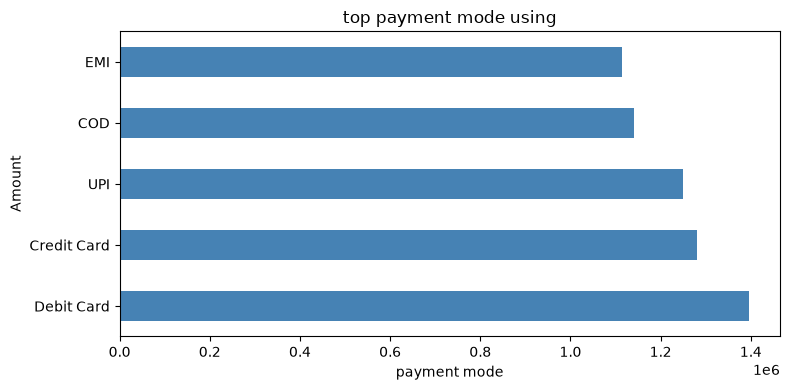

In [7]:
#Profit by payment mode
top_paymentmode=df.groupby('PaymentMode')['Amount'].sum().sort_values(ascending=False)
top_paymentmode.plot(kind='barh',figsize=(8,4),color='steelblue')
plt.title('top payment mode using')
plt.xlabel('payment mode')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

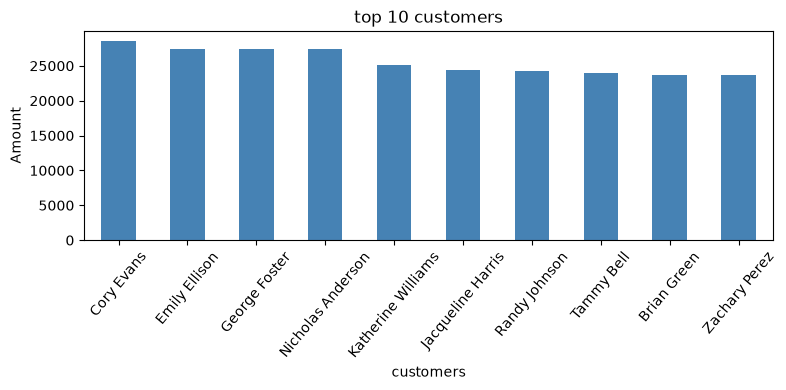

In [10]:
#Top 10 customers
top_customers=df.groupby('CustomerName')['Amount'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar',figsize=(8,4),color='steelblue')
plt.title('top 10 customers')
plt.xlabel('customers')
plt.ylabel('Amount')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

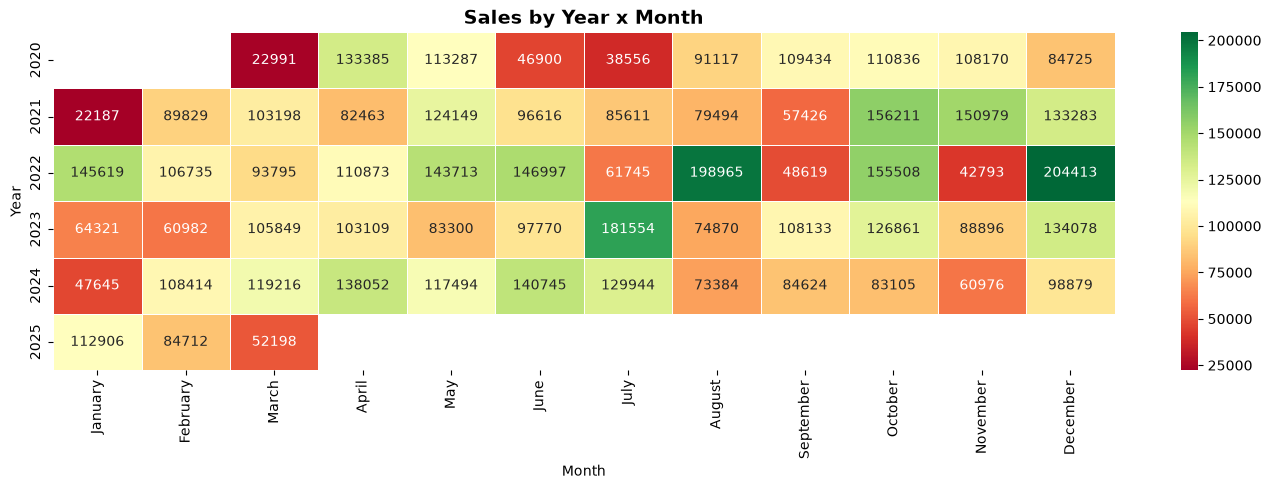

In [11]:
#Seasonality heatmap
df["year"] = df["Year-Month"].str[:4]
df["month"] = pd.to_datetime(df["Year-Month"], format="%Y-%m").dt.month_name()

pivot = df.pivot_table(values="Amount", index="year", columns="month", aggfunc="sum")

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
pivot = pivot.reindex(columns=month_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", linewidths=0.5, linecolor="white")
plt.title("Sales by Year x Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

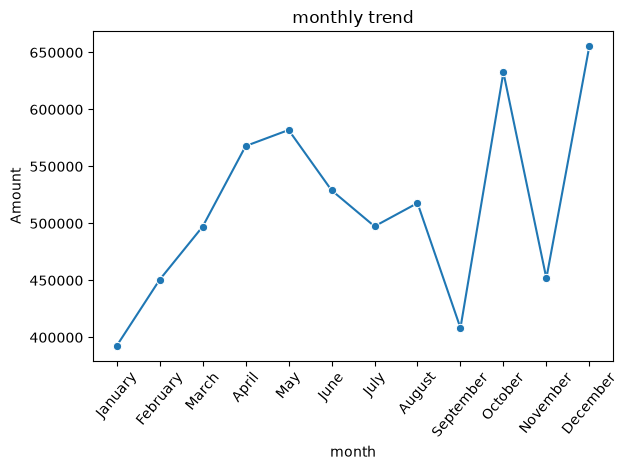

In [12]:
#Monthly trend line
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
monthly_sum = df.groupby('month')['Amount'].sum().reset_index()
sns.lineplot(data=monthly_sum, x='month', y='Amount', marker='o')
plt.title('monthly trend')
plt.xlabel('month')
plt.ylabel('Amount')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()

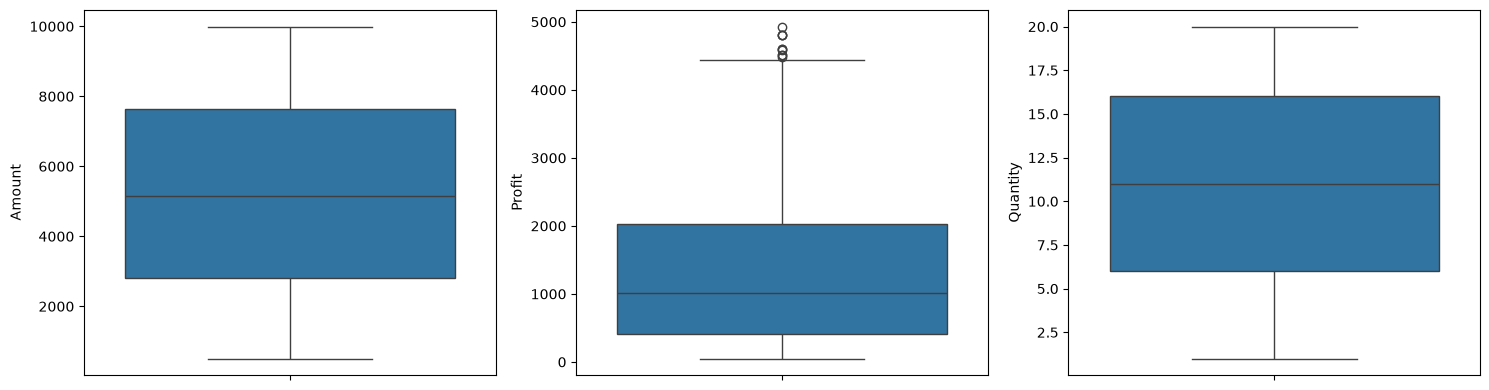

In [25]:
#Outlier check
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.boxplot(y=df['Amount'], ax=axes[0])
sns.boxplot(y=df['Profit'], ax=axes[1])
sns.boxplot(y=df['Quantity'], ax=axes[2])
plt.tight_layout()
plt.show()

In [ ]:
#Profit margin by category
df['ProfitMargin'] = df['Profit'] / df['Amount']
df.groupby('Category')['ProfitMargin'].mean().sort_values(ascending=False)

Category
Furniture          0.263009
Electronics        0.261223
Office Supplies    0.257450
Name: ProfitMargin, dtype: float64

<Axes: >

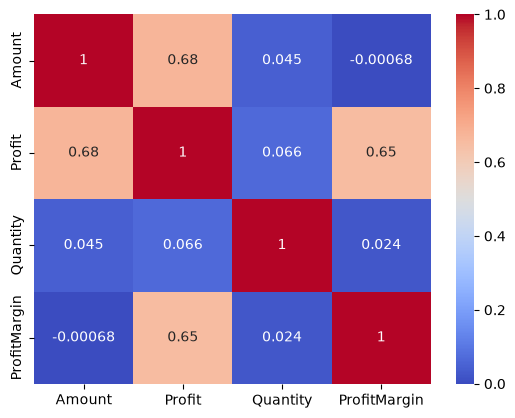

In [ ]:
#Correlation check
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [ ]:
#Profit by state
df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

State
Florida       308706
New York      308506
California    278814
Texas         257780
Illinois      240372
Ohio          216519
Name: Profit, dtype: int64

In [ ]:
#Category × payment mode breakdown
pd.crosstab(df['Category'], df['PaymentMode'], values=df['Profit'], aggfunc='sum')

PaymentMode,COD,Credit Card,Debit Card,EMI,UPI
Category,,,,,
Electronics,60998,130724,114019,96786,116053
Furniture,89821,105621,137441,116983,90676
Office Supplies,104925,113047,124261,82182,127160
